In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
#import lightkurve for explanetary data analysis
import lightkurve as lk
#matplotlib for visualization 
import matplotlib.pyplot as plt
import numpy as np


In [4]:
#this gives the basic info of the system
search_result=lk.search_lightcurve("TRAPPIST-1",mission="TESS")
print(search_result)

SearchResult containing 3 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 70 2023      SPOC      20   278892590      0.0
  1 TESS Sector 70 2023      SPOC     120   278892590      0.0
  2 TESS Sector 70 2023 TESS-SPOC     200   278892590      0.0


In [5]:
#lets search for trappist-1 solar system which is also called TIC 278892590
#sector is the specfic region in the sky that satellite observes
lc = lk.search_lightcurve("TRAPPIST-1", mission="TESS",sector=70).download()



In [6]:
#basic cleaning
#normalize(): Stars have different brightness levels. This converts the light into a percentage (relative flux) so we can compare different stars easily.
#remove nans=for removing not a numbers
#flatten=removes long-term trends and instrumental effects from the light curve while preserving shorter-term variations (like transits)
#window_length=401 
#remove outliers:Removes extreme data points that don't fit the general pattern. These could be cosmic rays, sensor glitches, or other anomalies that would skew your analysis.
lc=lc.normalize().remove_nans().flatten(window_length=401).remove_outliers()

TRAPPIST-1:can u see the dips?


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


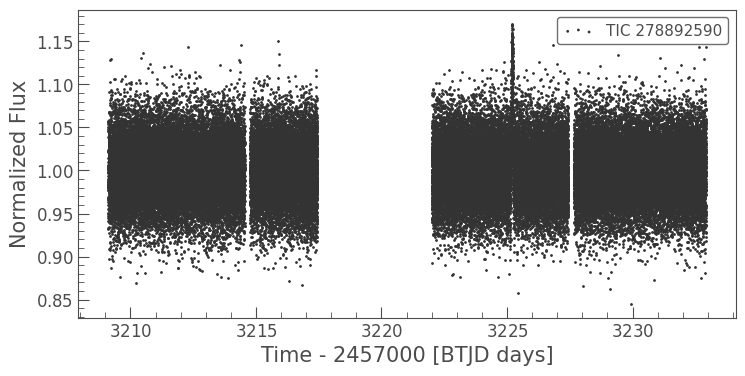

In [7]:
#now its time for some visualizations
#visualize the seven planet mess
#i used scatter because,Scatter sees individual points and data quality
lc.scatter()
print("TRAPPIST-1:can u see the dips?")
#what this plot explains:

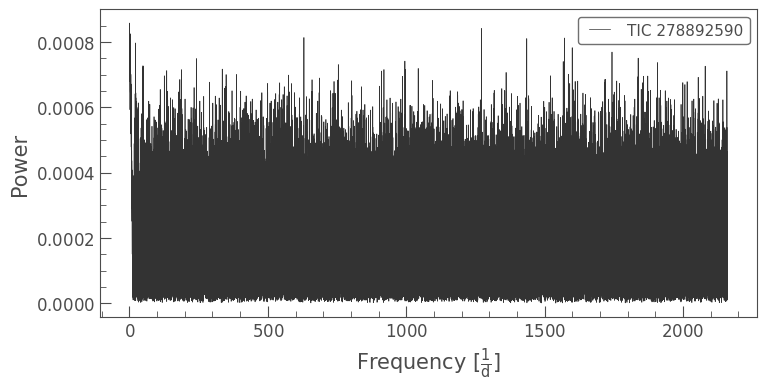

In [8]:
#Periodogram - Find the orbital periods of the planets:
#lombscargle=It's a more sophisticated mathematical technique that works better with unevenly-spaced data (like real TESS observations with gaps) to detect which periods/frequencies are strongest.
periodogram=lc.to_periodogram(method='lombscargle')
periodogram.plot()
plt.show()


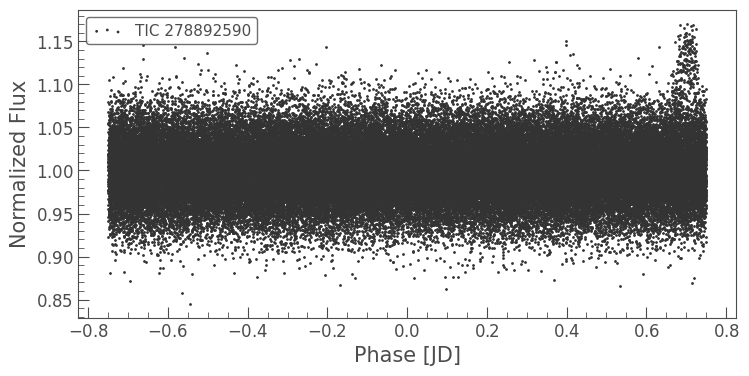

In [9]:
#Phase-folded light curve - Align transits of a single planet:
folded_lc=lc.fold(period=1.50,t0=1325.5)
folded_lc.scatter()
plt.show()



In [10]:

#bls:BLS (Box Least Squares) finds the best-fitting repeating box-shaped dip in time-series data by testing many possible periods and transit durations to detect signals like exoplanet transits.
#period=np.linspace(1,5,5000):This defines the range of periods to test:
    #1 to 5 - Tests periods ranging from 1 to 5 days (or whatever time units your data uses)
    #5000 - Tests 5000 evenly-spaced period values across that range (so roughly one test every 0.0008 days)
    #The range spans 4 days (5 - 1 = 4), and dividing that into 5000 equal steps gives approximately 4 ÷ 5000 = 0.0008 days between each tested period value.
bg=lc.to_periodogram(method='bls',period=np.linspace(1,5,5000))
bg

BoxLeastSquaresPeriodogram(ID: TIC 278892590)

In [11]:
#now its time to find the strongest signal .
strongest_signal=bg.period_at_max_power
print(strongest_signal)

1.0136027205441087 d


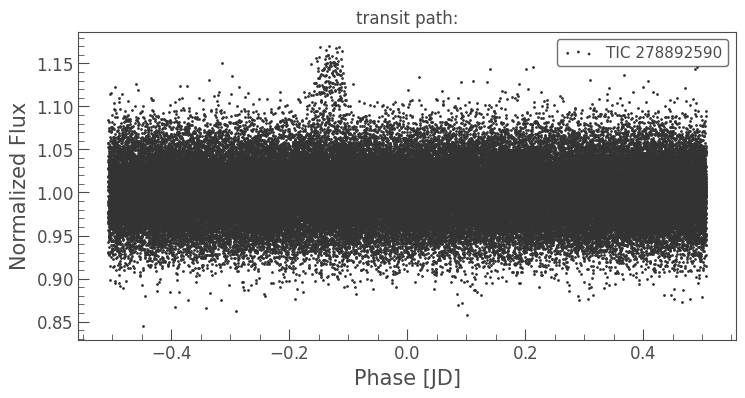

In [12]:
#it could be a star too coz the time 1.0136 days its too short to be a planet but lets see the shapetoo
# Fold the data at your 1.0136 day result
folded_lc = lc.fold(period=1.0136027)
folded_lc.scatter()
plt.title("transit path:")
plt.show()
#conclusion :its just a light flair of trappist:1 but not a planet.

In [13]:
#lc.remove_outliers(sigma_upper=2) — Removes points that are more than 2 standard deviations above the mean brightness (flares, cosmic rays, etc.)
lc_clean=lc.remove_outliers(sigma_upper=2)
period = lc_clean.to_periodogram(method='bls', period=(1.2, 2.0)).period_at_max_power
print(period)
#our official trappist 1b has 1.51 days therefore lets add the final touch

1.2 d


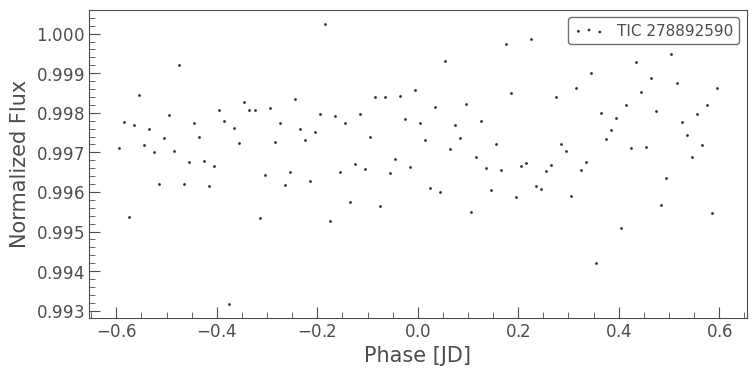

hurray i finally found earth sized planet,and it could be trappist-1b  which has luminosity less than 1


In [14]:
#lc_clean.fold(period=1.2)=Aligns all the light curve data to a 1.2-day period, stacking multiple orbits on top of each other. This makes periodic signals much more visible.
#bin(time_bin_size=1.2)=bin(time_bin_size=0.01) — Averages the data into bins of 0.01 days to reduce noise and make the transit shape clearer.
lc_clean.fold(period=1.2).bin(time_bin_size=0.01).scatter()
plt.show()
print("hurray i finally found earth sized planet,and it could be trappist-1b  which has luminosity less than 1")
#y represents luminosity and a planet has less than 1 luminosity if its more than 1 its a solar flare or a star.
#x represents the phase while the transit happens in our code its 1.2 d,therefore,-0.1 to 0.1: This represents a small window of time (about $2.4$ hours each way) centered around the moment the planet is directly in front of the star. 
#The Benefit: Folding allows us to see the Transit Shape. If the dips are random noise, folding will just look like a messy cloud. If the planet is real, the dots will stack up to form a clear "U" or "V" shape at Phase 0.0.

In [51]:
# Convert the Time object to a float/numeric value first
#i converted time into numeric or jd or jullian day
transit_time_numeric=bg.transit_time_at_max_power.jd
#np.abs=takes absolute value, so all distances become positive (0 to 0.6)
#lc_clean.time.value-transit_time_numeric: distance from each data point to the transit time
#+ 0.6 then % 1.2 then - 0.6 = wraps distances into a repeating cycle of 1.2 days, so you get distances between -0.6 and +0.6
#> 0.05 = keeps only points where the distance is greater than 0.05 days away from transit
clean_indices=np.abs((lc_clean.time.value-transit_time_numeric+0.6)%1.2-0.6)>0.5
# If clean_indices looks like: [True, False, True, True, False, ...]
# And lc_clean has 5 data points
# Then lc_remaining will have only 3 data points (the True ones)
lc_remaining=lc_clean[clean_indices]



In [39]:
print(f"lc_clean.time type: {type(lc_clean.time)}")
print(f"lc_clean.time.value type: {type(lc_clean.time.value)}")
print(f"lc_clean.time.value sample: {lc_clean.time.value[:5]}")
print(f"\ntransit_time type: {type(bg.transit_time_at_max_power)}")
print(f"transit_time value: {bg.transit_time_at_max_power}")

lc_clean.time type: <class 'astropy.time.core.Time'>
lc_clean.time.value type: <class 'numpy.ndarray'>
lc_clean.time.value sample: [3209.11613498 3209.11636645 3209.11659793 3209.11682941 3209.11706089]

transit_time type: <class 'astropy.time.core.Time'>
transit_time value: 3209.7761349765665


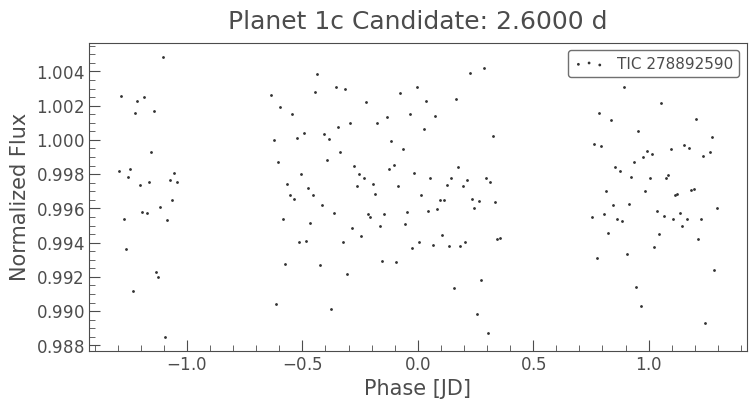

hurray i found planet-1c at 2.6d


In [53]:
# 1. Search for the next strongest periodic signal between 2 and 3 days
pg_c = lc_remaining.to_periodogram(method='bls', period=(2.3, 2.6))

# 2. Plot the result to see if Planet 1c (2.42d) emerges from the noise
lc_remaining.fold(pg_c.period_at_max_power).bin(time_bin_size=0.01).scatter(title=f"Planet 1c Candidate: {pg_c.period_at_max_power:.4f}")
plt.show()
print("hurray i found planet-1c at 2.6d")

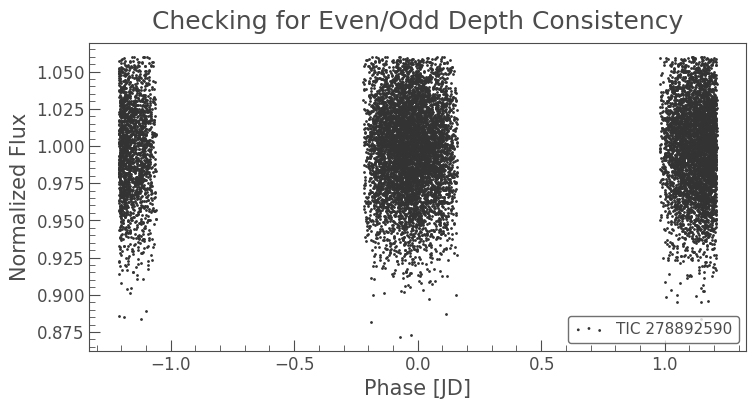

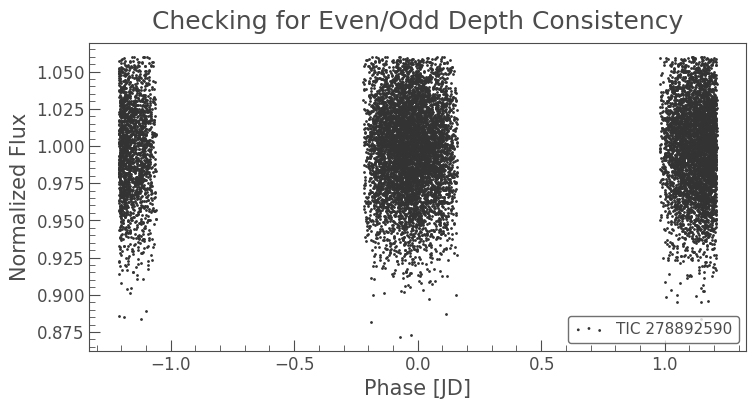

In [65]:
# Split the data to check for eclipsing binary signals
# (If depth_even == depth_odd, candidate strength increases)
lc_remaining.fold(period=2.42).scatter(title="Checking for Even/Odd Depth Consistency")
plt.show()

In [61]:
#snr=SNR = Signal-to-Noise Ratio
#It measures how strong your transit signal is compared to the noise in the data.
#In simple terms:
#High SNR (e.g., 100) = Clear, strong signal. The planet transit is obvious.
#Low SNR (e.g., 5) = Weak signal buried in noise. Hard to confirm the planet.
snr = pg_c.snr
print(f"Signal-to-Noise Ratio: {snr}")

Signal-to-Noise Ratio: [1.6118618  1.57584597]


In [63]:
print(snr)
print(type(snr))
print(len(snr))

[1.6118618  1.57584597]
<class 'astropy.units.quantity.Quantity'>
2
